In [1]:
# ============================================================
# PHASE 4: Regression Analysis
# - Linear Regression  → Predict MonthlyCharges
# - Logistic Regression → Predict Churn (Yes/No)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

print("All libraries loaded ✅")

All libraries loaded ✅


In [2]:
df = pd.read_csv('../data/cleaned/telco_churn_cleaned.csv')

print("Shape:", df.shape)
print("\nChurn value counts:")
print(df['Churn'].value_counts())
df.head()

Shape: (7032, 21)

Churn value counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Make a copy for modeling
df_model = df.copy()

# Encode binary Yes/No columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'Churn', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    df_model[col] = df_model[col].map({'Yes': 1, 'No': 0,
                                        'No phone service': 0,
                                        'No internet service': 0})

# Encode gender
df_model['gender'] = df_model['gender'].map({'Male': 1, 'Female': 0})

# One-hot encode multi-category columns
df_model = pd.get_dummies(df_model,
                           columns=['Contract', 'PaymentMethod', 'InternetService'],
                           drop_first=True)

# Drop customerID (not a feature)
df_model.drop(columns=['customerID'], inplace=True)

print("Encoding complete ✅")
print("New shape:", df_model.shape)
df_model.head()

Encoding complete ✅
New shape: (7032, 24)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,True,False,False,False
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,True,False,False,False,True,False,False
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,True,False,False
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,True,False,False,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,False,False,False,True,False,True,False


In [4]:
# ─────────────────────────────────────────
# PART A: Linear Regression
# Goal: Predict MonthlyCharges from features
# ─────────────────────────────────────────

# Features and target
X_lin = df_model.drop(columns=['MonthlyCharges', 'TotalCharges', 'Churn'])
y_lin = df_model['MonthlyCharges']

# Train-test split
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=42
)

print("Training size:", X_train_l.shape)
print("Testing size: ", X_test_l.shape)

Training size: (5625, 21)
Testing size:  (1407, 21)


In [5]:
# Train model
lr = LinearRegression()
lr.fit(X_train_l, y_train_l)

# Predict
y_pred_l = lr.predict(X_test_l)

# Metrics
mae  = mean_absolute_error(y_test_l, y_pred_l)
rmse = np.sqrt(mean_squared_error(y_test_l, y_pred_l))
r2   = r2_score(y_test_l, y_pred_l)

print("=" * 40)
print("  LINEAR REGRESSION RESULTS")
print("=" * 40)
print(f"  MAE  : {mae:.2f}")
print(f"  RMSE : {rmse:.2f}")
print(f"  R²   : {r2:.4f}")
print("=" * 40)

  LINEAR REGRESSION RESULTS
  MAE  : 0.78
  RMSE : 1.04
  R²   : 0.9988


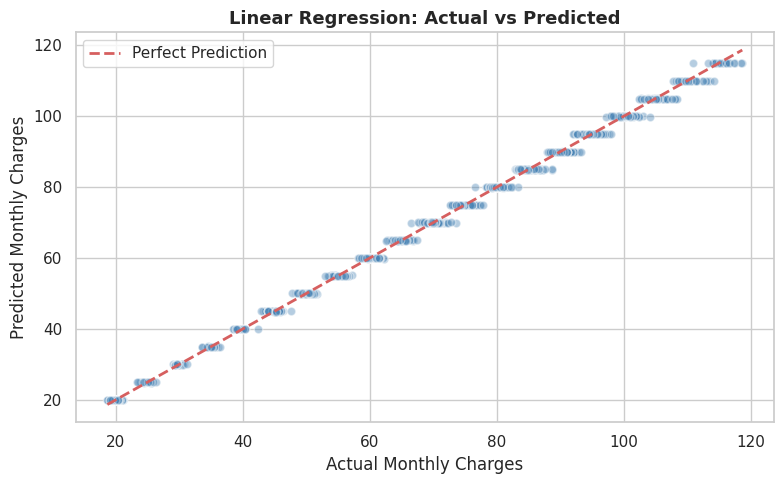

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test_l, y_pred_l, alpha=0.4, color='steelblue', edgecolors='white')
plt.plot([y_test_l.min(), y_test_l.max()],
         [y_test_l.min(), y_test_l.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Monthly Charges')
plt.ylabel('Predicted Monthly Charges')
plt.title('Linear Regression: Actual vs Predicted', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/linear_actual_vs_predicted.png', dpi=150)
plt.show()

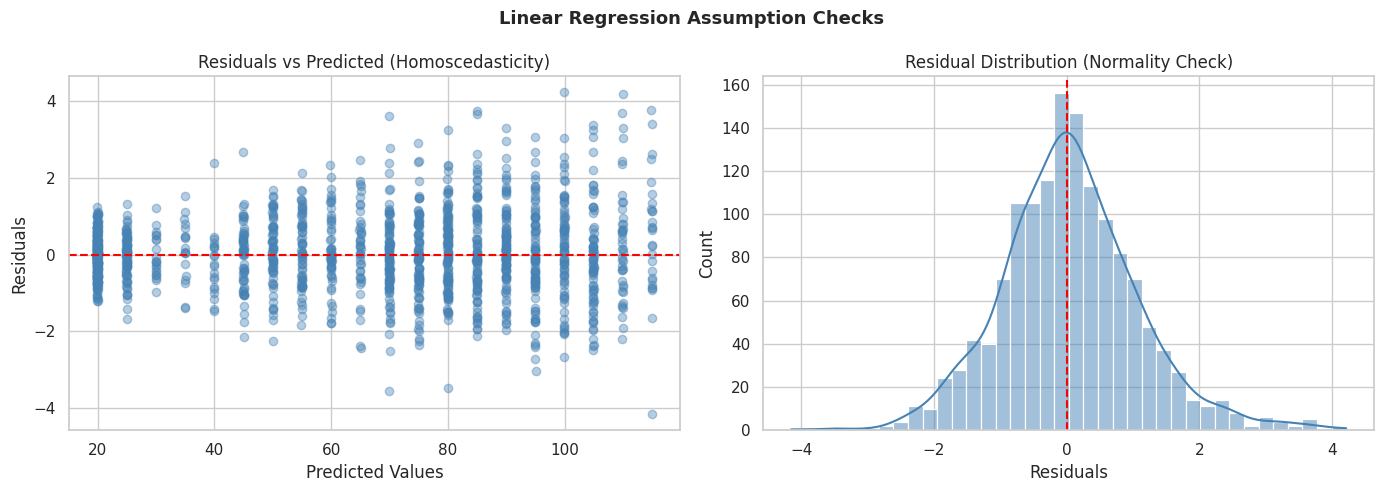

In [7]:
residuals = y_test_l - y_pred_l

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted (Homoscedasticity check)
axes[0].scatter(y_pred_l, residuals, alpha=0.4, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Predicted (Homoscedasticity)')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')

# Residual Distribution (Normality check)
sns.histplot(residuals, kde=True, ax=axes[1], color='steelblue')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Distribution (Normality Check)')
axes[1].set_xlabel('Residuals')

plt.suptitle('Linear Regression Assumption Checks', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/regression_assumptions.png', dpi=150)
plt.show()

In [10]:
# 1. Define your target variable (Churn)
# Convert 'Yes'/'No' to 1/0 so statsmodels can process it
y = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. Perform the split correctly
from sklearn.model_selection import train_test_split

# Note: changed 'test_test_size' to 'test_size'
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_numeric, y, test_size=0.2, random_state=42
)

print("Split successful! Training shape:", X_train_l.shape)

Split successful! Training shape: (5625, 7061)


In [11]:
# Add constant for intercept
X_train_sm = sm.add_constant(X_train_l)
X_test_sm  = sm.add_constant(X_test_l)

ols_model = sm.OLS(y_train_l, X_train_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Churn   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Mon, 20 Apr 2026   Prob (F-statistic):                nan
Time:                        19:54:29   Log-Likelihood:             1.4656e+05
No. Observations:                5625   AIC:                        -2.819e+05
Df Residuals:                       0   BIC:                        -2.445e+05
Df Model:                        5624                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [12]:
# ─────────────────────────────────────────
# PART B: Logistic Regression
# Goal: Predict Churn (1 = Yes, 0 = No)
# ─────────────────────────────────────────

X_log = df_model.drop(columns=['Churn', 'TotalCharges'])
y_log = df_model['Churn']

# Scale features (important for logistic regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# Train-test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_scaled, y_log, test_size=0.2, random_state=42, stratify=y_log
)

print("Training size:", X_train_c.shape)
print("Testing size: ", X_test_c.shape)
print("\nClass balance in training set:")
print(pd.Series(y_train_c).value_counts())

Training size: (5625, 22)
Testing size:  (1407, 22)

Class balance in training set:
Churn
0    4130
1    1495
Name: count, dtype: int64


In [13]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_c, y_train_c)

y_pred_c      = log_reg.predict(X_test_c)
y_pred_proba  = log_reg.predict_proba(X_test_c)[:, 1]

print("Model trained ✅")

Model trained ✅


In [14]:
print("=" * 45)
print("   LOGISTIC REGRESSION RESULTS")
print("=" * 45)
print(classification_report(y_test_c, y_pred_c,
                              target_names=['No Churn', 'Churn']))
print(f"  ROC-AUC Score: {roc_auc_score(y_test_c, y_pred_proba):.4f}")
print("=" * 45)

   LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

  ROC-AUC Score: 0.8333


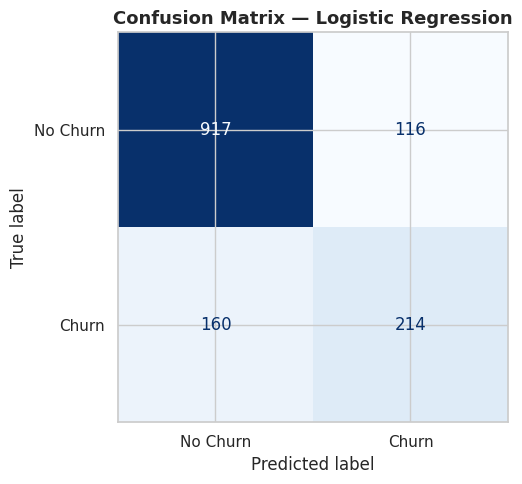

In [15]:
cm = confusion_matrix(y_test_c, y_pred_c)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Churn', 'Churn'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Logistic Regression',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix_logreg.png', dpi=150)
plt.show()

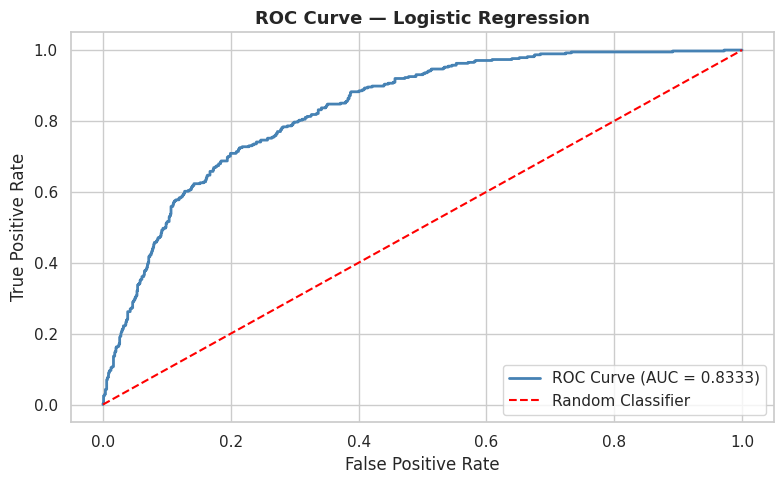

In [16]:
fpr, tpr, thresholds = roc_curve(y_test_c, y_pred_proba)
auc_score = roc_auc_score(y_test_c, y_pred_proba)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/figures/roc_curve_logreg.png', dpi=150)
plt.show()

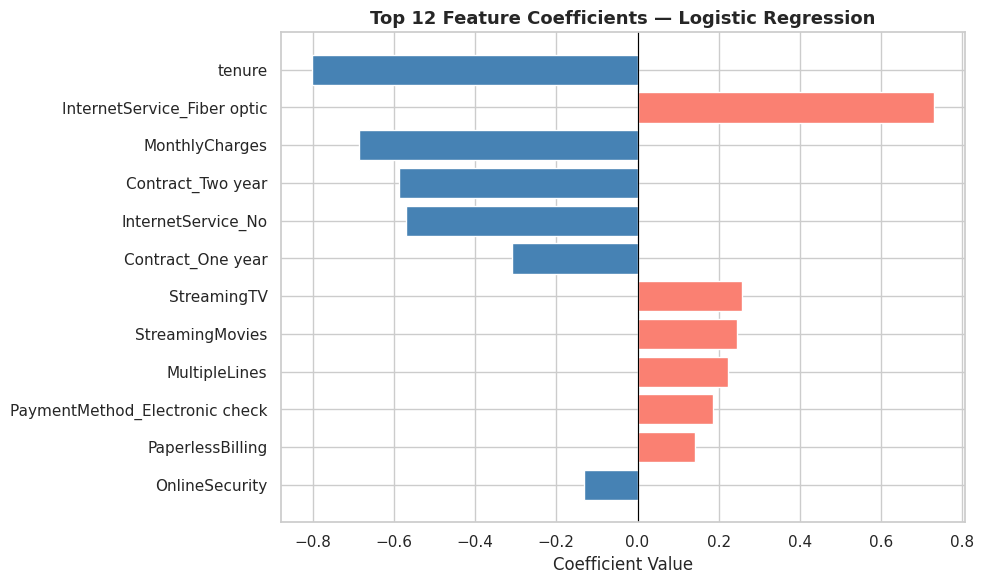

In [17]:
# Get feature names and coefficients
feature_names = X_log.columns.tolist()
coefficients  = log_reg.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', key=abs, ascending=False).head(12)

plt.figure(figsize=(10, 6))
colors = ['salmon' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Top 12 Feature Coefficients — Logistic Regression',
          fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/figures/logreg_coefficients.png', dpi=150)
plt.show()

In [18]:
results = {
    'Model': ['Linear Regression', 'Logistic Regression'],
    'Target': ['MonthlyCharges', 'Churn'],
    'Key Metric': ['R² Score', 'ROC-AUC'],
    'Score': [round(r2, 4), round(auc_score, 4)]
}

results_df = pd.DataFrame(results)
results_df.to_csv('../outputs/model_metrics/regression_results.csv', index=False)

print("Results saved ✅")
print(results_df)

Results saved ✅
                 Model          Target Key Metric   Score
0    Linear Regression  MonthlyCharges   R² Score  0.9988
1  Logistic Regression           Churn    ROC-AUC  0.8333
